In [1]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from itertools import product

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

In [2]:
train_direction = '/Users/yaxuanhu/Desktop/9517/EWS-Dataset/train'
validation_direction = '/Users/yaxuanhu/Desktop/9517/EWS-Dataset/validation'
test_direction = '/Users/yaxuanhu/Desktop/9517/EWS-Dataset/test'

In [3]:
def load_split(folder):
    all_png = glob(os.path.join(folder, '*.png'))
    all_png.sort()

    image_paths, mask_paths = [], []

    for p in all_png:
        (mask_paths if p.endswith('_mask.png') else image_paths).append(p)

    image_direction = {
        os.path.splitext(os.path.basename(p))[0]: p
        for p in image_paths
    }

    mask_direction = {
        Path(p).stem.replace('_mask', ''): p
        for p in mask_paths
    }

    common_names = sorted(image_direction.keys() & mask_direction.keys())

    print(f'{folder}')
    print('num of images:', len(image_paths))
    print('num of masks :', len(mask_paths))
    print('num of pairs :', len(common_names))

    images = []
    masks = []
    paired_image_paths = []
    paired_mask_paths = []

    for name in common_names:
        image = cv2.imread(image_direction[name])
        mask = cv2.imread(mask_direction[name], 0)

        if image is None:
            raise ValueError(f'Cannot read image: {image_direction[name]}')
        if mask is None:
            raise ValueError(f'Cannot read mask: {mask_direction[name]}')

        images.append(image)
        masks.append(mask)
        paired_image_paths.append(image_direction[name])
        paired_mask_paths.append(mask_direction[name])

    return images, masks, paired_image_paths, paired_mask_paths

In [4]:
train_images, train_masks, train_image_paths, train_mask_paths = load_split(train_direction)
validation_images, validation_masks, validation_image_paths, validation_mask_paths = load_split(validation_direction)
test_images, test_masks, test_image_paths, test_mask_paths = load_split(test_direction)

/Users/yaxuanhu/Desktop/9517/EWS-Dataset/train
num of images: 142
num of masks : 142
num of pairs : 142
/Users/yaxuanhu/Desktop/9517/EWS-Dataset/validation
num of images: 24
num of masks : 24
num of pairs : 24
/Users/yaxuanhu/Desktop/9517/EWS-Dataset/test
num of images: 24
num of masks : 24
num of pairs : 24


In [5]:
def extract_features(image):
    h, w = image.shape[:2]
    
    rgb = image.reshape(-1, 3)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = gray.reshape(-1, 1)

    sobelx = cv2.Sobel(gray.reshape(h, w), cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray.reshape(h, w), cv2.CV_32F, 0, 1, ksize=3)
    
    sobelx = sobelx.reshape(-1, 1)
    sobely = sobely.reshape(-1, 1)

    features = np.concatenate([rgb, gray, sobelx, sobely], axis=1)

    return features

In [6]:
def build_dataset(images, masks):
    X_list = []
    y_list = []

    for image, mask in zip(images, masks):
        X = extract_features(image)
        flat = mask.reshape(-1)
        binary = flat > 0
        y = binary.astype(np.uint8)

        X_list.append(X)
        y_list.append(y)

    X_all = np.vstack(X_list)
    y_all = np.hstack(y_list)

    return X_all, y_all

In [7]:
X_train, y_train = build_dataset(train_images, train_masks)
X_validation, y_validation = build_dataset(validation_images, validation_masks)

print('X_train shape     :', X_train.shape)
print('y_train shape     :', y_train.shape)
print('X_validation shape:', X_validation.shape)
print('y_validation shape:', y_validation.shape)

X_train shape     : (17395000, 6)
y_train shape     : (17395000,)
X_validation shape: (2940000, 6)
y_validation shape: (2940000,)


In [8]:
def sample_pixels(X, y, n_samples, random_state=42):
    n_samples = min(n_samples, len(X))
    rng = np.random.default_rng(random_state)
    index = rng.permutation(len(X))[:n_samples]
    return X[index], y[index]

In [9]:
rng = np.random.default_rng(42)

index_train = rng.choice(len(X_train), 50000, replace=False)
X_train_sample = X_train[index_train]
y_train_sample = y_train[index_train]

index_validation = rng.choice(len(X_validation), 20000, replace=False)
X_validation_sample = X_validation[index_validation]
y_validation_sample = y_validation[index_validation]

print('sampled train:', X_train_sample.shape, y_train_sample.shape)
print('sampled value  :', X_validation_sample.shape, y_validation_sample.shape)

sampled train: (50000, 6) (50000,)
sampled value  : (20000, 6) (20000,)


In [10]:
def compute_metrics(predict_result, real_tag, eps=1e-7):
    predict_result = predict_result.reshape(-1).astype(bool)
    real_tag = (real_tag.reshape(-1) > 0).astype(bool)

    TP = np.logical_and(predict_result, real_tag).sum()
    FP = np.logical_and(predict_result, ~real_tag).sum()
    FN = np.logical_and(~predict_result, real_tag).sum()

    precision = TP / (TP + FP + eps)
    recall = TP / (TP + FN + eps)
    precision_recall = 2 * precision * recall / (precision + recall + eps)
    intersection_union = TP / (TP + FP + FN + eps)

    return precision, recall, precision_recall, intersection_union

In [11]:
best_model, best_precision_recall, best_parameters = None, -1, None

parameters_grid = [
    {'n_estimators': n, 'max_depth': d}
    for n, d in product([30, 50, 80], [10, 15])
]

for param in parameters_grid:
    model = RandomForestClassifier(
        **param,
        random_state=42,
        n_jobs=-1
    )
    
    start_train = time.time(); model.fit(X_train_sample, y_train_sample)
    train_time = time.time() - start_train

    validation_predict = model.predict(X_validation_sample)
    precision, recall, precision_recall, intersection_union = compute_metrics(validation_predict, y_validation_sample)

    print(f"param={param}, train_time={train_time:.2f}s, "
          f"precision={precision:.4f}, recall={recall:.4f}, "
          f"precision_recall={precision_recall:.4f}, intersection_union={intersection_union:.4f}")

    if precision_recall > best_precision_recall:
        best_precision_recall = precision_recall
        best_model = model
        best_parameters = param

print('\nBest parameters                 :', best_parameters)
print('Best validation precision_recall:', best_precision_recall)

param={'n_estimators': 30, 'max_depth': 10}, train_time=0.18s, precision=0.8964, recall=0.9783, precision_recall=0.9356, intersection_union=0.8789
param={'n_estimators': 30, 'max_depth': 15}, train_time=0.15s, precision=0.9221, recall=0.9605, precision_recall=0.9409, intersection_union=0.8885
param={'n_estimators': 50, 'max_depth': 10}, train_time=0.18s, precision=0.8979, recall=0.9785, precision_recall=0.9365, intersection_union=0.8805
param={'n_estimators': 50, 'max_depth': 15}, train_time=0.23s, precision=0.9227, recall=0.9603, precision_recall=0.9411, intersection_union=0.8888
param={'n_estimators': 80, 'max_depth': 10}, train_time=0.28s, precision=0.8963, recall=0.9788, precision_recall=0.9357, intersection_union=0.8792
param={'n_estimators': 80, 'max_depth': 15}, train_time=0.35s, precision=0.9222, recall=0.9603, precision_recall=0.9409, intersection_union=0.8884

Best parameters                 : {'n_estimators': 50, 'max_depth': 15}
Best validation precision_recall: 0.941121445

In [12]:
log_model = LogisticRegression(max_iter=200)

start_train = time.time()
log_model.fit(X_train_sample, y_train_sample)
train_time = time.time() - start_train

validation_predict = log_model.predict(X_validation_sample)

precision, recall, precision_recall, intersection_union = compute_metrics(
    validation_predict, y_validation_sample
)

print("Logistic Regression Validation Results:")
print("precision            :", precision)
print("recall               :", recall)
print("precision_recall     :", precision_recall)
print("intersection_union   :", intersection_union)
print("train_time           :", train_time)

Logistic Regression Validation Results:
precision            : 0.9352492333955983
recall               : 0.9620745305093744
precision_recall     : 0.9484721973363509
intersection_union   : 0.9019944979305227


In [13]:
def predict_image(model, image):
    X = extract_features(image)
    predict = model.predict(X)
    predict_mask = predict.reshape(image.shape[0], image.shape[1])
    return predict_mask

In [18]:
test_precision = []
test_recall = []
test_precision_recall = []
test_intersection_union = []
test_times = []

for image, real_tag_mask in zip(test_images, test_masks):
    start_test = time.time()
    predict_mask = predict_image(best_model, image)
    test_time = time.time() - start_test

    precision, recall, precision_recall, intersection_union = compute_metrics(predict_mask, real_tag_mask)

    test_precision.append(precision)
    test_recall.append(recall)
    test_precision_recall.append(precision_recall)
    test_intersection_union.append(intersection_union)
    test_times.append(test_time)

print('Random Forest Test Results :')
print('Precision                  :', np.mean(test_precision))
print('Recall                     :', np.mean(test_recall))
print('Precision_recall_score     :', np.mean(test_precision_recall))
print('Intersection_union         :', np.mean(test_intersection_union))
print('Average test time per image:', np.mean(test_times), 'seconds')

Random Forest Test Results :
Precision                  : 0.896860088109665
Recall                     : 0.9418610862876461
Precision_recall_score     : 0.9147852688898933
Intersection_union         : 0.8492781279458157
Average test time per image: 0.04667673508326212 seconds


In [19]:
log_precision = []
log_recall = []
log_precision_recall = []
log_intersection_union = []
log_time = []

for image, mask in zip(test_images, test_masks):
    start = time.time()
    predict_mask = predict_image(log_model, image)
    end = time.time()

    precision, recall, precision_recall, intersection_union = compute_metrics(predict_mask, mask)

    log_precision.append(precision)
    log_recall.append(recall)
    log_precision_recall.append(precision_recall)
    log_intersection_union.append(intersection_union)
    log_time.append(end - start)

print("Logistic Regression Test Results:")
print("Precision                       :", np.mean(log_precision))
print("Recall                          :", np.mean(log_recall))
print("Precision_recall-score          :", np.mean(log_precision_recall))
print("Intersection_union              :", np.mean(log_intersection_union))
print("Average test time per image     :", np.mean(log_time), 'seconds')

Logistic Regression Test Results:
Precision                       : 0.9081708994766617
Recall                          : 0.9377826314761831
Precision_recall-score          : 0.9204434679594989
Intersection_union              : 0.8592790253113577
Average test time per image     : 0.004185885190963745 seconds


In [20]:
index = 0

test_image = test_images[index]
real_tag_mask = test_masks[index]
predict_mask = predict_image(best_model, test_image)

precision, recall, precision_recall, intersection_union = compute_metrics(predict_mask, real_tag_mask)

print("One Image Test Results:")
print('Precision         :', precision)
print('Recall            :', recall)
print('Precision_recall  :', precision_recall)
print('Intersection_union:', intersection_union)

One Image Test Results:
Precision         : 0.9767218683643509
Recall            : 0.9929720349144876
Precision_recall  : 0.9847798689144229
Intersection_union: 0.9700161937848166


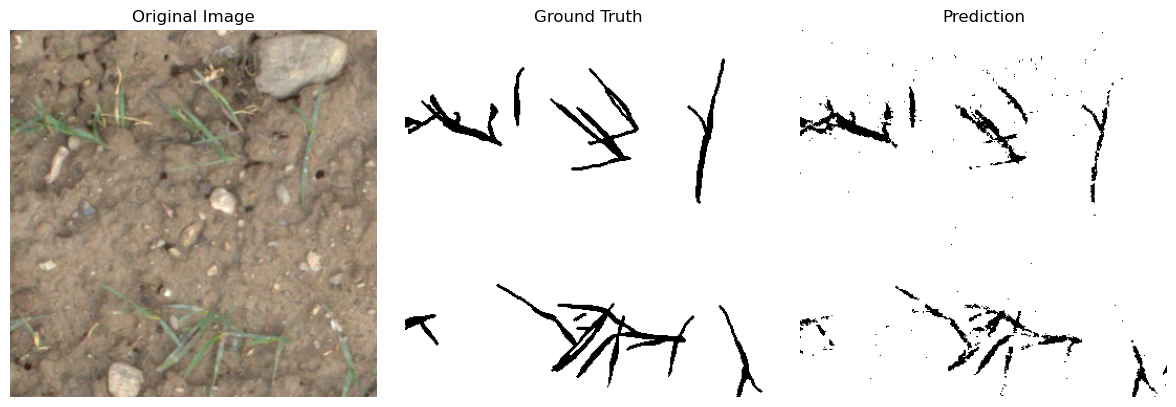

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Ground Truth')
plt.imshow(real_tag_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Prediction')
plt.imshow(predict_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()